TASK 4: DATA PREPROCESSING
Original Dataset Shape: (7043, 50)
Dataset Shape After Feature Selection: (7043, 39)

PREPROCESSING SETUP SUMMARY
Original Dataset: (7043, 50)
After Feature Selection: (7043, 39)
Training Partition: (5634, 38)
Testing Partition: (1409, 38)
Remaining Training Missing Values: 0
Remaining Testing Missing Values: 0

Training Class Distribution:
Churn Label
0    4139
1    1495
Name: count, dtype: int64

Testing Class Distribution:
Churn Label
0    1035
1     374
Name: count, dtype: int64

TRANSFORMATION AND SCALING

Skewness Before and After Log1p:
                 Feature  Before Log1p  After Log1p
           Total Refunds          4.32         3.46
Total Extra Data Charges          4.13         2.88


C:\Users\jonnn\AppData\Local\Temp\ipykernel_24696\530265.py:101: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(


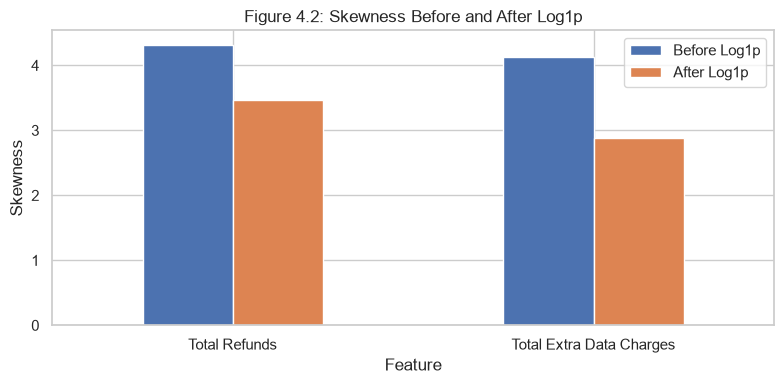


Standardisation completed using training-set parameters only.

CLASS BALANCING AND ENCODING

Class Distribution BEFORE SMOTENC:
Churn Label
0    4139
1    1495
Name: count, dtype: int64

Class Distribution AFTER SMOTENC:
Churn Label
0    4139
1    4139
Name: count, dtype: int64

ENCODING SUMMARY
Categorical Features Before Encoding: 22
Numerical Features: 16
Final Training Matrix: (8278, 46)
Final Testing Matrix: (1409, 46)
Final Number of Predictor Features: 46


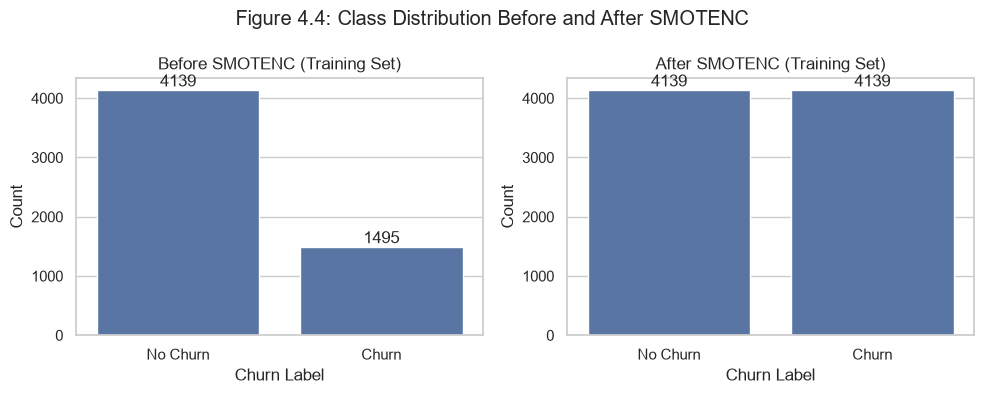


FINAL PREPROCESSING SUMMARY
                  Stage  Rows
       Original Dataset  7043
After Feature Selection  7043
Training Before SMOTENC  5634
               Test Set  1409
 Training After SMOTENC  8278


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTENC


# ==========================================================
# DATA CLEANING AND FEATURE SELECTION
# ==========================================================

df = pd.read_csv("telco.csv")

sns.set_theme(style="whitegrid")

print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

print(f"Original Dataset Shape: {df.shape}")


# Remove:
# - identifiers
# - leakage/post-outcome variables
# - highly redundant variable
# - constant variables
# - very high-cardinality geographic variables
cols_to_drop = [
    "Customer ID",
    "Churn Reason",
    "Churn Category",
    "Churn Score",
    "Customer Status",
    "Total Revenue",
    "Country",
    "State",
    "Quarter",
    "City",
    "Zip Code"
]

df_clean = df.drop(
    columns=[
        col for col in cols_to_drop
        if col in df.columns
    ]
).copy()

print(
    f"Dataset Shape After Feature Selection: "
    f"{df_clean.shape}"
)


# Convert target to binary
df_clean["Churn Label"] = (
    df_clean["Churn Label"]
    .map({
        "Yes": 1,
        "No": 0
    })
)

# Safety check
assert df_clean["Churn Label"].notna().all(), \
    "Unexpected value found in Churn Label"


X = df_clean.drop(
    columns=["Churn Label"]
).copy()

y = df_clean[
    "Churn Label"
].copy()


# ==========================================================
# STRATIFIED SPLIT AND MISSING-VALUE HANDLING
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()


# Identify feature types
categorical_cols = (
    X_train
    .select_dtypes(
        include=["object", "category", "bool"]
    )
    .columns
    .tolist()
)

numeric_cols = (
    X_train
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)


# --------------------------
# Missing-value treatment
# --------------------------

# Offer:
# Missing value retained as an explicit category
if "Offer" in X_train.columns:

    X_train["Offer"] = (
        X_train["Offer"]
        .fillna("No_Recorded_Offer")
    )

    X_test["Offer"] = (
        X_test["Offer"]
        .fillna("No_Recorded_Offer")
    )


# Internet Type:
# In this dataset, missing Internet Type corresponds
# to customers with no Internet Service
if "Internet Type" in X_train.columns:

    X_train["Internet Type"] = (
        X_train["Internet Type"]
        .fillna("No_Internet")
    )

    X_test["Internet Type"] = (
        X_test["Internet Type"]
        .fillna("No_Internet")
    )


# Safety fallback for any other categorical missing values
for col in categorical_cols:

    X_train[col] = (
        X_train[col]
        .fillna("Missing")
    )

    X_test[col] = (
        X_test[col]
        .fillna("Missing")
    )


# ==========================================================
# PREPROCESSING SETUP SUMMARY
# ==========================================================

print("\n" + "=" * 60)
print("PREPROCESSING SETUP SUMMARY")
print("=" * 60)

print(
    f"Original Dataset: "
    f"{df.shape}"
)

print(
    f"After Feature Selection: "
    f"{df_clean.shape}"
)

print(
    f"Training Partition: "
    f"{X_train.shape}"
)

print(
    f"Testing Partition: "
    f"{X_test.shape}"
)

print(
    f"Remaining Training Missing Values: "
    f"{X_train.isnull().sum().sum()}"
)

print(
    f"Remaining Testing Missing Values: "
    f"{X_test.isnull().sum().sum()}"
)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())


# ==========================================================
# TRANSFORMATION AND SCALING
# ==========================================================

print("\n" + "=" * 60)
print("TRANSFORMATION AND SCALING")
print("=" * 60)


# Only strongly right-skewed variables are transformed.
# Task 3 identified these as the strongest cases.
skewed_cols = [
    "Total Refunds",
    "Total Extra Data Charges"
]

skewness_results = []


for col in skewed_cols:

    if col in X_train.columns:

        skew_before = X_train[col].skew()

        X_train[col] = np.log1p(
            X_train[col]
        )

        X_test[col] = np.log1p(
            X_test[col]
        )

        skew_after = X_train[col].skew()

        skewness_results.append({
            "Feature": col,
            "Before Log1p": round(
                skew_before,
                2
            ),
            "After Log1p": round(
                skew_after,
                2
            )
        })


skewness_table = pd.DataFrame(
    skewness_results
)

print(
    "\nSkewness Before and After Log1p:"
)

print(
    skewness_table.to_string(
        index=False
    )
)


# ----------------------------------------------------------
# Skewness before and after Log1p
# ----------------------------------------------------------

skew_plot = skewness_table.set_index(
    "Feature"
)

skew_plot.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title(
    "Skewness Before and After Log1p"
)

plt.ylabel("Skewness")

plt.xlabel("Feature")

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# --------------------------
# Standardisation
# --------------------------

scaler = StandardScaler()

# Fit ONLY on training data
X_train[numeric_cols] = (
    scaler.fit_transform(
        X_train[numeric_cols]
    )
)

# Test data only uses parameters
# learned from training data
X_test[numeric_cols] = (
    scaler.transform(
        X_test[numeric_cols]
    )
)

print(
    "\nStandardisation completed "
    "using training-set parameters only."
)


# ==========================================================
# CLASS BALANCING AND CATEGORICAL ENCODING
# ==========================================================

print("\n" + "=" * 60)
print("CLASS BALANCING AND ENCODING")
print("=" * 60)


# SMOTENC requires the positions
# of categorical variables
categorical_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_cols
]


smotenc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)


# Apply ONLY to training data
X_train_resampled, y_train_resampled = (
    smotenc.fit_resample(
        X_train,
        y_train
    )
)


# Preserve DataFrame structure if necessary
if not isinstance(
    X_train_resampled,
    pd.DataFrame
):

    X_train_resampled = pd.DataFrame(
        X_train_resampled,
        columns=X_train.columns
    )


print(
    "\nClass Distribution BEFORE SMOTENC:"
)

print(
    y_train.value_counts()
)

print(
    "\nClass Distribution AFTER SMOTENC:"
)

print(
    pd.Series(
        y_train_resampled,
        name="Churn Label"
    ).value_counts()
)


# ----------------------------------------------------------
# One-Hot Encoding
# Encoder is fitted on TRAINING DATA ONLY
# ----------------------------------------------------------

encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)


encoder.fit(
    X_train_resampled[
        categorical_cols
    ]
)


train_cat_encoded = encoder.transform(
    X_train_resampled[
        categorical_cols
    ]
)

test_cat_encoded = encoder.transform(
    X_test[
        categorical_cols
    ]
)


encoded_feature_names = (
    encoder.get_feature_names_out(
        categorical_cols
    )
)


train_cat_df = pd.DataFrame(
    train_cat_encoded,
    columns=encoded_feature_names
).reset_index(
    drop=True
)


test_cat_df = pd.DataFrame(
    test_cat_encoded,
    columns=encoded_feature_names
).reset_index(
    drop=True
)


# Keep numerical variables
train_num_df = (
    X_train_resampled[
        numeric_cols
    ]
    .reset_index(
        drop=True
    )
)

test_num_df = (
    X_test[
        numeric_cols
    ]
    .reset_index(
        drop=True
    )
)


# Combine numerical + encoded categorical variables
X_train_final = pd.concat(
    [
        train_num_df,
        train_cat_df
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        test_num_df,
        test_cat_df
    ],
    axis=1
)


# ==========================================================
# ENCODING SUMMARY
# ==========================================================

print("\n" + "=" * 60)
print("ENCODING SUMMARY")
print("=" * 60)

print(
    f"Categorical Features Before Encoding: "
    f"{len(categorical_cols)}"
)

print(
    f"Numerical Features: "
    f"{len(numeric_cols)}"
)

print(
    f"Final Training Matrix: "
    f"{X_train_final.shape}"
)

print(
    f"Final Testing Matrix: "
    f"{X_test_final.shape}"
)

print(
    f"Final Number of Predictor Features: "
    f"{X_train_final.shape[1]}"
)


# ==========================================================
# CLASS DISTRIBUTION BEFORE AND AFTER SMOTENC
# ==========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)


# BEFORE SMOTENC
ax1 = sns.countplot(
    x=y_train,
    ax=axes[0]
)

axes[0].set_title(
    "Before SMOTENC (Training Set)"
)

axes[0].set_xlabel(
    "Churn Label"
)

axes[0].set_ylabel(
    "Count"
)

axes[0].set_xticks(
    [0, 1]
)

axes[0].set_xticklabels([
    "No Churn",
    "Churn"
])


# Add count labels
for bar in ax1.patches:

    height = bar.get_height()

    ax1.annotate(
        f"{int(height)}",
        (
            bar.get_x()
            + bar.get_width() / 2,
            height
        ),
        ha="center",
        va="bottom"
    )


# AFTER SMOTENC
ax2 = sns.countplot(
    x=y_train_resampled,
    ax=axes[1]
)

axes[1].set_title(
    "After SMOTENC (Training Set)"
)

axes[1].set_xlabel(
    "Churn Label"
)

axes[1].set_ylabel(
    "Count"
)

axes[1].set_xticks(
    [0, 1]
)

axes[1].set_xticklabels([
    "No Churn",
    "Churn"
])


for bar in ax2.patches:

    height = bar.get_height()

    ax2.annotate(
        f"{int(height)}",
        (
            bar.get_x()
            + bar.get_width() / 2,
            height
        ),
        ha="center",
        va="bottom"
    )


plt.suptitle(
    "Class Distribution Before and After SMOTENC"
)

plt.tight_layout()

plt.show()


# ==========================================================
# FINAL PREPROCESSING SUMMARY
# ==========================================================

print("\n" + "=" * 60)
print("FINAL PREPROCESSING SUMMARY")
print("=" * 60)


summary = pd.DataFrame({
    "Stage": [
        "Original Dataset",
        "After Feature Selection",
        "Training Before SMOTENC",
        "Test Set",
        "Training After SMOTENC"
    ],

    "Rows": [
        len(df),
        len(df_clean),
        len(X_train),
        len(X_test),
        len(X_train_final)
    ]
})


print(
    summary.to_string(
        index=False
    )
)